In [3]:
#############################################################
#  Preprocessing– TF-IDF   
#############################################################


# ======================================================
# 0. IMPORTS
# ======================================================

import pandas as pd
import numpy as np
import re
import nltk

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# NLTK resources
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

pd.set_option("display.max_colwidth", None)



# ======================================================
# 1. CHARGEMENT DU DATASET PRINCIPAL (train.csv)
# ======================================================

df = pd.read_csv("train.csv", header=None, names=["label", "title", "text"])
df = df.rename(columns={"label": "sentiment"})  # 1=neg, 2=pos



# ======================================================
# 2. FILTRAGE DES LANGUES (ENGLISH FILTER appliqué avant pipeline)
# ======================================================

COMMON_EN_WORDS = {
    "the","and","is","it","to","was","with","for","this","that","of","on","in","my","you","but","we",
    "they","if","at","from","as","have","has","had","not","be","been","so","very","really","would",
    "one","two","more","like","good","bad","great","excellent","product","movie","book","music","time"
}
word_pattern = re.compile(r"[a-zA-Z]+")

def looks_english(text, ascii_threshold=0.70, english_word_threshold=0.30):
    """Heuristique rapide et proche de langdetect."""
    if not isinstance(text, str) or len(text) < 5:
        return True

    letters = [c for c in text if c.isalpha()]
    if len(letters) == 0:
        return False

    ascii_ratio = sum(c.isascii() for c in letters) / len(letters)
    if ascii_ratio < ascii_threshold:
        return False

    words = word_pattern.findall(text.lower())
    if len(words) == 0:
        return False

    english_like = sum(w in COMMON_EN_WORDS for w in words)
    english_ratio = english_like / len(words)

    return english_ratio >= english_word_threshold


# Application du filtre AVANT l'entraînement
df = df[df["text"].apply(looks_english)].reset_index(drop=True)



# ======================================================
# 3. SPLIT TRAIN / TEST (80/20)
# ======================================================

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["sentiment"]
)



# ======================================================
# 4. TRANSFORMEURS PERSONNALISÉS
# ======================================================

# (a) Concatenation title + text
class TitleConcat(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        X["text"] = X["title"].fillna("") + " " + X["text"].fillna("")
        return X


# (b) Nettoyage léger
class TextCleaner(BaseEstimator, TransformerMixin):
    def clean(self, text):
        if not isinstance(text, str):
            return ""
        text = text.lower()
        text = re.sub(r"[^a-z\s']", " ", text)
        text = re.sub(r"\s+", " ", text).strip()
        return text
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        X["text"] = X["text"].apply(self.clean)
        return X


# (c) Stopwords remover
class StopwordRemover(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.stopwords = set(stopwords.words("english"))
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        X["text"] = X["text"].apply(
            lambda t: " ".join([w for w in t.split() if w not in self.stopwords])
        )
        return X


# (d) Lemmatizer
class Lemmatizer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.lemma = WordNetLemmatizer()
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        X["text"] = X["text"].apply(
            lambda t: " ".join(self.lemma.lemmatize(w) for w in t.split())
        )
        return X


# (e) Wrapper TF-IDF
class TfidfVectorizerWrapper(BaseEstimator, TransformerMixin):
    def __init__(self, max_features=50_000):
        self.vectorizer = TfidfVectorizer(
            max_features=max_features,
            ngram_range=(1,2),
            sublinear_tf=True
        )
    
    def fit(self, X, y=None):
        self.vectorizer.fit(X["text"])
        return self
    
    def transform(self, X):
        return self.vectorizer.transform(X["text"])



# ======================================================
# 5. PIPELINE TF-IDF FINAL
# ======================================================

tfidf_pipeline = Pipeline([
    ("concat", TitleConcat()),
    ("cleaner", TextCleaner()),
    ("stopwords", StopwordRemover()),
    ("lemma", Lemmatizer()),
    ("tfidf", TfidfVectorizerWrapper())
])



# ======================================================
# 6. APPLICATION DU PIPELINE
# ======================================================

X_train = tfidf_pipeline.fit_transform(train_df)
X_test  = tfidf_pipeline.transform(test_df)

y_train = train_df["sentiment"].values
y_test  = test_df["sentiment"].values



# ======================================================
# 7. AFFICHAGE DES DIMENSIONS
# ======================================================

#print("X_train shape :", X_train.shape)
#print("X_test shape  :", X_test.shape)
#print("y_train :", len(y_train))
#print("y_test  :", len(y_test))


d:\Users\utheza\.conda\envs\sbert\lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


=== Régression Logistique ===
Accuracy: 0.9170927665908342
F1 score: 0.916109002159916
              precision    recall  f1-score   support

           1       0.92      0.91      0.92    292875
           2       0.92      0.92      0.92    298340

    accuracy                           0.92    591215
   macro avg       0.92      0.92      0.92    591215
weighted avg       0.92      0.92      0.92    591215



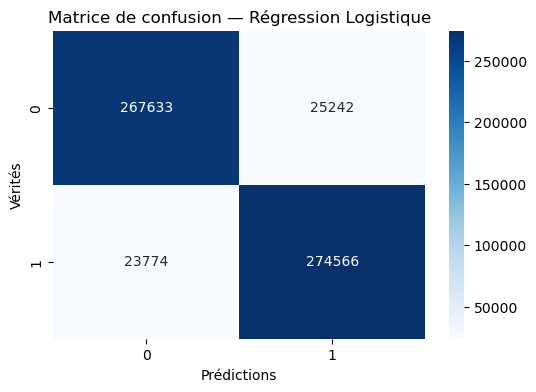


=== Naive Bayes ===
Accuracy: 0.8806204172762869
F1 score: 0.8790148259506418
              precision    recall  f1-score   support

           1       0.88      0.88      0.88    292875
           2       0.88      0.89      0.88    298340

    accuracy                           0.88    591215
   macro avg       0.88      0.88      0.88    591215
weighted avg       0.88      0.88      0.88    591215



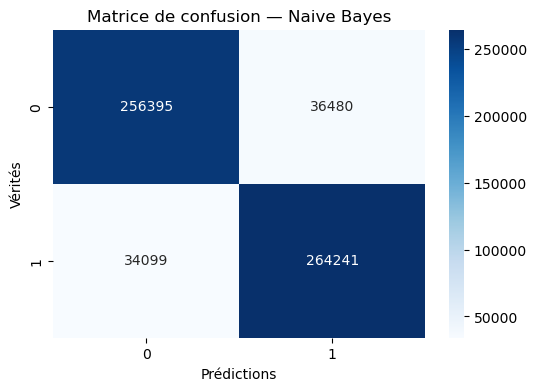


=== Linear SVM ===
Accuracy: 0.9195876288659793
F1 score: 0.918594875043878
              precision    recall  f1-score   support

           1       0.92      0.92      0.92    292875
           2       0.92      0.92      0.92    298340

    accuracy                           0.92    591215
   macro avg       0.92      0.92      0.92    591215
weighted avg       0.92      0.92      0.92    591215



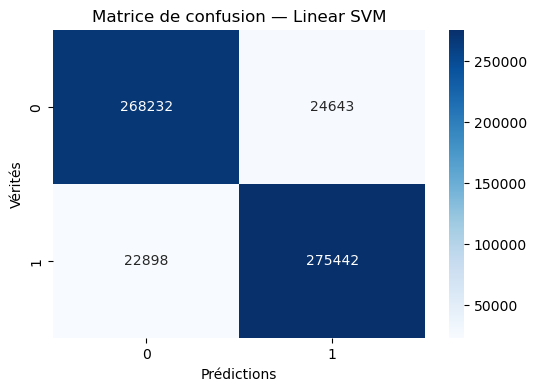

In [2]:
#############################################################
#  Modélisation – Step 1 (Baselines TF-IDF)
#############################################################

# Imports
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)

import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------------------------------------
#         Fonction utilitaire — matrice de confusion
# -----------------------------------------------------------
def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Prédictions")
    plt.ylabel("Vérités")
    plt.show()


#############################################################
#  MODELE 1 — Régression Logistique
#############################################################

logreg = LogisticRegression(max_iter=200)

logreg.fit(X_train, y_train)
y_pred_logreg = logreg.predict(X_test)

print("=== Régression Logistique ===")
print("Accuracy:", accuracy_score(y_test, y_pred_logreg))
print("F1 score:", f1_score(y_test, y_pred_logreg))
print(classification_report(y_test, y_pred_logreg))

cm = confusion_matrix(y_test, y_pred_logreg)
plot_confusion_matrix(cm, "Matrice de confusion — Régression Logistique")


#############################################################
#  MODELE 2 — Naive Bayes
#############################################################

nb = MultinomialNB()

nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

print("\n=== Naive Bayes ===")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("F1 score:", f1_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

cm = confusion_matrix(y_test, y_pred_nb)
plot_confusion_matrix(cm, "Matrice de confusion — Naive Bayes")


#############################################################
#  MODELE 3 — Linear SVM
#############################################################

svm = LinearSVC()

svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

print("\n=== Linear SVM ===")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("F1 score:", f1_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

cm = confusion_matrix(y_test, y_pred_svm)
plot_confusion_matrix(cm, "Matrice de confusion — Linear SVM")


Taille du jeu d’entraînement : (2364857, 50000)

===== Optimisation Régression Logistique =====
Meilleurs hyperparamètres : {'C': 3, 'penalty': 'l2', 'solver': 'liblinear'}

Scores optimisés :
Accuracy : 0.919726326294157
F1-score : 0.9187277699670007
              precision    recall  f1-score   support

           1       0.92      0.92      0.92    292875
           2       0.92      0.92      0.92    298340

    accuracy                           0.92    591215
   macro avg       0.92      0.92      0.92    591215
weighted avg       0.92      0.92      0.92    591215



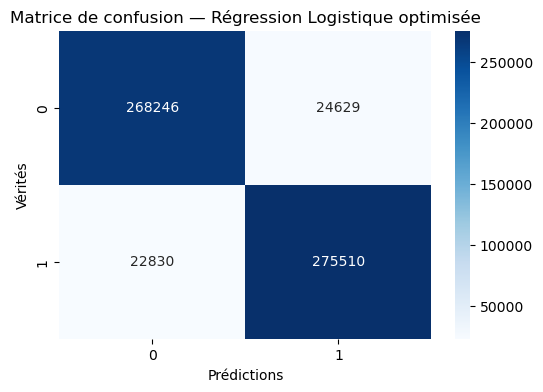


===== Optimisation Linear SVM =====
Meilleurs hyperparamètres : {'C': 0.1}

Scores optimisés :
Accuracy : 0.9197973664402966
F1-score : 0.9187963563938643
              precision    recall  f1-score   support

           1       0.92      0.92      0.92    292875
           2       0.92      0.92      0.92    298340

    accuracy                           0.92    591215
   macro avg       0.92      0.92      0.92    591215
weighted avg       0.92      0.92      0.92    591215



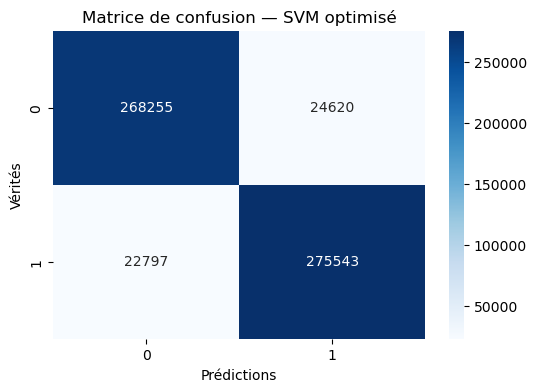

In [3]:
#############################################################
#        Modélisation Step 2 — Optimisation (TF-IDF)
#############################################################

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report
import numpy as np

import warnings
warnings.filterwarnings("ignore")

print("Taille du jeu d’entraînement :", X_train.shape)

#########################################################
# 1. Optimisation de la Régression Logistique
#########################################################

logreg = LogisticRegression(max_iter=500)

param_grid_logreg = {
    "C": [0.1, 1, 3, 5],
    "penalty": ["l2"],
    "solver": ["liblinear", "lbfgs"],
}

grid_logreg = GridSearchCV(
    logreg,
    param_grid_logreg,
    cv=3,
    scoring="f1",
    n_jobs=1,
    verbose=0
)

print("\n===== Optimisation Régression Logistique =====")
grid_logreg.fit(X_train, y_train)

print("Meilleurs hyperparamètres :", grid_logreg.best_params_)

best_logreg = grid_logreg.best_estimator_
y_pred_logreg_opt = best_logreg.predict(X_test)

print("\nScores optimisés :")
print("Accuracy :", accuracy_score(y_test, y_pred_logreg_opt))
print("F1-score :", f1_score(y_test, y_pred_logreg_opt))
print(classification_report(y_test, y_pred_logreg_opt))

cm = confusion_matrix(y_test, y_pred_logreg_opt)
plot_confusion_matrix(cm, "Matrice de confusion — Régression Logistique optimisée")


#########################################################
# 2. Optimisation du SVM Linéaire (modèle baseline gagnant)
#########################################################

svm = LinearSVC()

param_grid_svm = {
    "C": [0.1, 0.5, 1, 2, 3],
}

grid_svm = GridSearchCV(
    svm,
    param_grid_svm,
    cv=3,
    scoring="f1",
    n_jobs=1,
    verbose=0
)

print("\n===== Optimisation Linear SVM =====")
grid_svm.fit(X_train, y_train)

print("Meilleurs hyperparamètres :", grid_svm.best_params_)

best_svm = grid_svm.best_estimator_
y_pred_svm_opt = best_svm.predict(X_test)

print("\nScores optimisés :")
print("Accuracy :", accuracy_score(y_test, y_pred_svm_opt))
print("F1-score :", f1_score(y_test, y_pred_svm_opt))
print(classification_report(y_test, y_pred_svm_opt))

cm = confusion_matrix(y_test, y_pred_svm_opt)
plot_confusion_matrix(cm, "Matrice de confusion — SVM optimisé")



===== Random Forest =====
Répartition des classes dans l'échantillon Random Forest :
2    50.505
1    49.495
Name: proportion, dtype: float64
2    40404
1    39596
Name: count, dtype: int64
Accuracy : 0.8672428811853555
F1-score : 0.8660189070250967
              precision    recall  f1-score   support

           1       0.87      0.87      0.87    292875
           2       0.87      0.87      0.87    298340

    accuracy                           0.87    591215
   macro avg       0.87      0.87      0.87    591215
weighted avg       0.87      0.87      0.87    591215



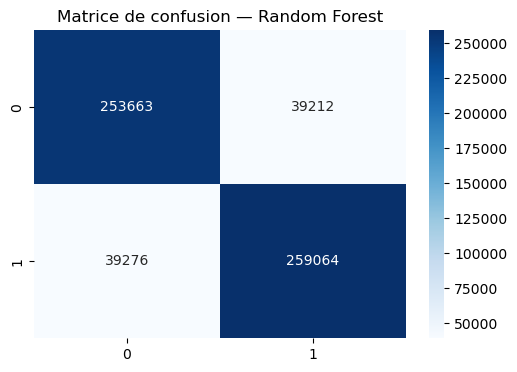


===== XGBoost =====
Répartition des classes dans l'échantillon XGBoost :
1    50.376667
0    49.623333
Name: proportion, dtype: float64
1    60452
0    59548
Name: count, dtype: int64
Accuracy : 0.8580296508038531
F1-score : 0.8594027695652684
              precision    recall  f1-score   support

           0       0.86      0.86      0.86    292875
           1       0.86      0.86      0.86    298340

    accuracy                           0.86    591215
   macro avg       0.86      0.86      0.86    591215
weighted avg       0.86      0.86      0.86    591215



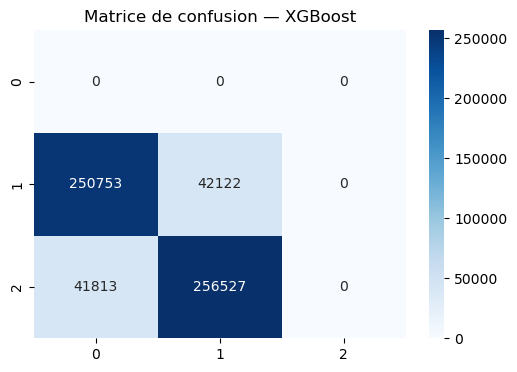

In [5]:
#############################################################
#        # STEP 3 — Modèles avancés
#############################################################

# 1 — IMPORTS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# Modèles avancés
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Interprétabilité
#import shap


#############################################################
# 2 — RANDOM FOREST (échantillonné)
#############################################################

print("\n===== Random Forest =====")

# Sous-échantillonnage raisonnable
#N_RF = 30000
N_RF = 80000
rf_X = X_train[:N_RF]
rf_y = y_train[:N_RF]

# Vérification de l’équilibre des classes dans l’échantillon RF
print("Répartition des classes dans l'échantillon Random Forest :")
print(pd.Series(rf_y).value_counts(normalize=True) * 100)
print(pd.Series(rf_y).value_counts())


rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    n_jobs=-1,
    random_state=42
)

rf.fit(rf_X, rf_y)

y_pred_rf = rf.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("F1-score :", f1_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matrice de confusion — Random Forest")
plt.show()


#############################################################
# 3 — XGBOOST (TF-IDF échantillonné)
#############################################################

print("\n===== XGBoost =====")

# Sous-échantillonnage raisonnable
#N_XGB = 50000
N_XGB = 120000
xgb_X = X_train[:N_XGB]
xgb_y = y_train[:N_XGB]

# Remap obligatoire pour XGBoost
xgb_y = np.where(xgb_y == 1, 0, 1)

# Vérification de l’équilibre des classes dans l’échantillon XGBoost
print("Répartition des classes dans l'échantillon XGBoost :")
print(pd.Series(xgb_y).value_counts(normalize=True) * 100)
print(pd.Series(xgb_y).value_counts())


xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    n_jobs=-1,
    eval_metric="logloss"
)

xgb.fit(xgb_X, xgb_y)

# Prédictions
y_test_remap = np.where(y_test == 1, 0, 1)
y_pred_xgb = xgb.predict(X_test)

print("Accuracy :", accuracy_score(y_test_remap, y_pred_xgb))
print("F1-score :", f1_score(y_test_remap, y_pred_xgb))
print(classification_report(y_test_remap, y_pred_xgb))

cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matrice de confusion — XGBoost")
plt.show()




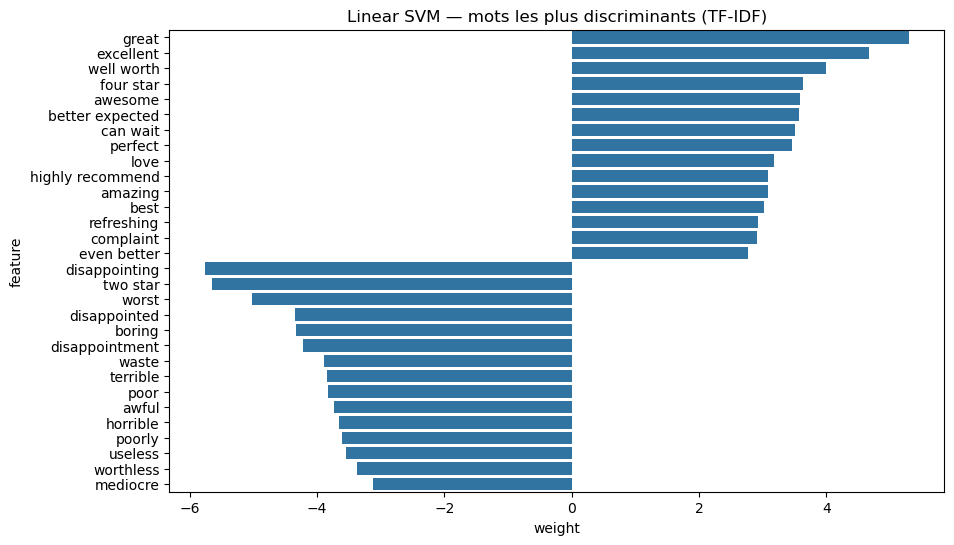

In [6]:
# ======================================================
# Interprétabilité — Linear SVM (TF-IDF)
# ======================================================

feature_names = tfidf_pipeline.named_steps["tfidf"].vectorizer.get_feature_names_out()
coef = best_svm.coef_[0]

df_importance_svm = pd.DataFrame({
    "feature": feature_names,
    "weight": coef
})

top_positive = df_importance_svm.sort_values("weight", ascending=False).head(15)
top_negative = df_importance_svm.sort_values("weight").head(15)

plt.figure(figsize=(10,6))
sns.barplot(
    x="weight",
    y="feature",
    data=pd.concat([top_positive, top_negative])
)
plt.title("Linear SVM — mots les plus discriminants (TF-IDF)")
plt.show()

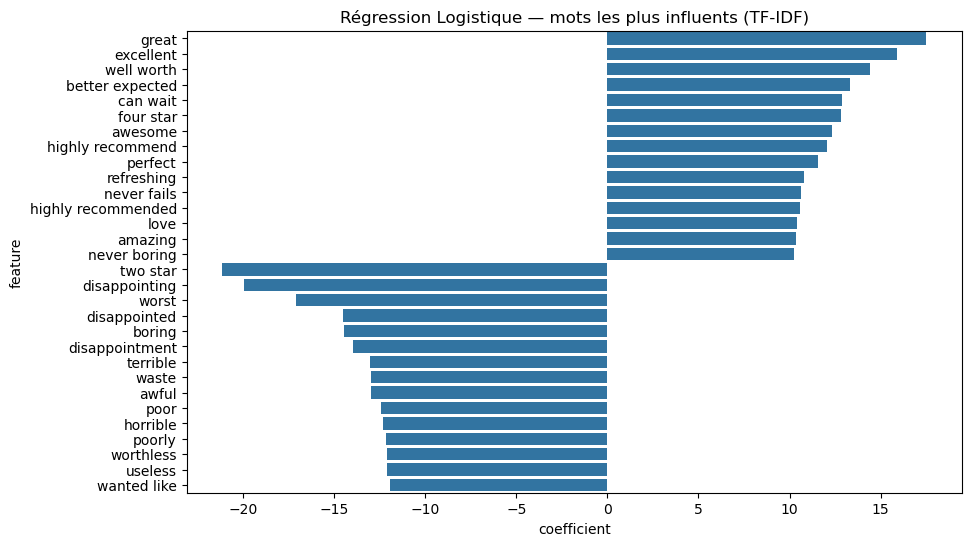

In [7]:
# ======================================================
# Interprétabilité — Régression Logistique (TF-IDF)
# ======================================================

# Récupération des noms des features (mots / n-grams)
feature_names = tfidf_pipeline.named_steps["tfidf"].vectorizer.get_feature_names_out()

# Coefficients du modèle
coef = best_logreg.coef_[0]

# Création DataFrame importance
df_importance_logreg = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coef
})

# Mots les plus positifs / négatifs
top_positive = df_importance_logreg.sort_values("coefficient", ascending=False).head(15)
top_negative = df_importance_logreg.sort_values("coefficient").head(15)

# Visualisation
plt.figure(figsize=(10,6))
sns.barplot(
    x="coefficient",
    y="feature",
    data=pd.concat([top_positive, top_negative])
)
plt.title("Régression Logistique — mots les plus influents (TF-IDF)")
plt.show()

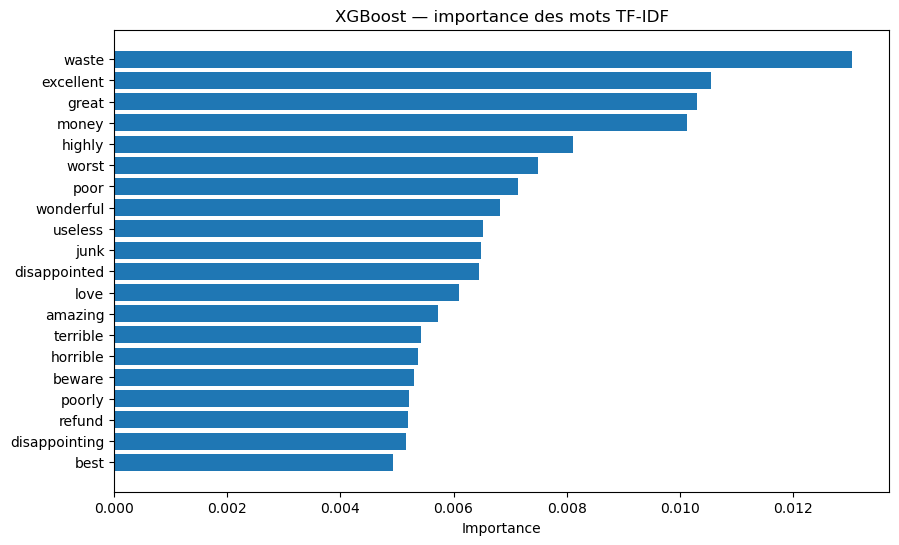

In [ ]:
# ======================================================
# Interprétabilité — XGBoost (feature_importances_)
# ======================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

feature_names = tfidf_pipeline.named_steps["tfidf"].vectorizer.get_feature_names_out()
importances = xgb.feature_importances_

df_xgb_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

# Top 20 mots les plus importants
df_xgb_importance = df_xgb_importance.sort_values(
    "importance", ascending=False
).head(20)

plt.figure(figsize=(10,6))
plt.barh(df_xgb_importance["feature"], df_xgb_importance["importance"])
plt.gca().invert_yaxis()
plt.title("XGBoost — importance des mots TF-IDF")
plt.xlabel("Importance")
plt.show()


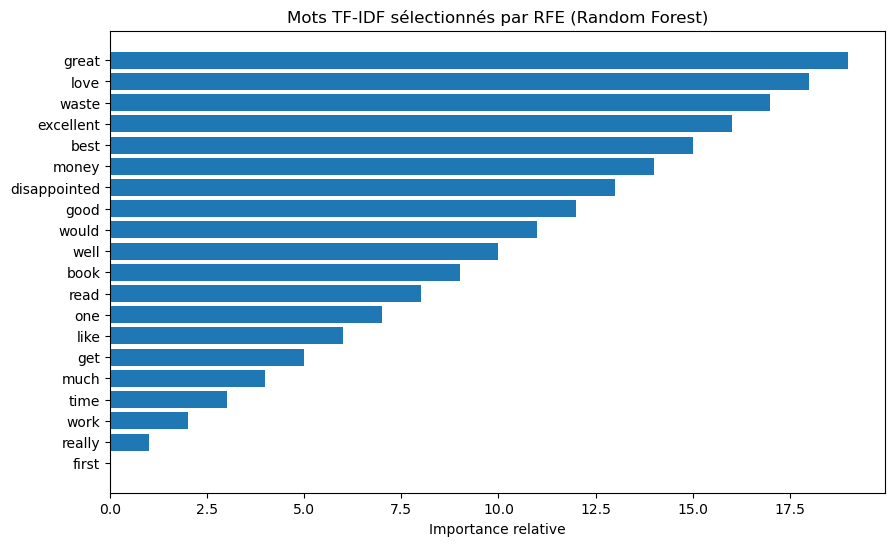

In [12]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

# ======================================================
# Interprétabilité — Random Forest via RFE
# ======================================================

# Pré-sélection des features importantes (Random Forest)
importances = rf.feature_importances_
feature_names = tfidf_pipeline.named_steps["tfidf"].vectorizer.get_feature_names_out()

# On garde les 200 mots les plus importants
top_k = 200
top_idx = np.argsort(importances)[-top_k:]

X_rf_reduced = rf_X[:, top_idx]
selected_features = feature_names[top_idx]

rf_small = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rfe = RFE(
    estimator=rf_small,
    n_features_to_select=20,
    step=10
)

rfe.fit(X_rf_reduced, rf_y)

final_features = selected_features[rfe.support_]

# Visualisation
df_rf_importance = pd.DataFrame({
    "feature": final_features
})

plt.figure(figsize=(10,6))
plt.barh(df_rf_importance["feature"], range(len(df_rf_importance)))
plt.title("Mots TF-IDF sélectionnés par RFE (Random Forest)")
plt.xlabel("Importance relative")
plt.show()

In [7]:
# Sauvegarde du modèle SVM

import joblib
import os

os.makedirs("models", exist_ok=True)

# Sauvegarde du vectorizer TF-IDF
joblib.dump(tfidf_pipeline, "models/tfidf_pipeline.pkl")

# Sauvegarde du meilleur SVM
joblib.dump(best_svm, "models/svm_sentiment.pkl")

['models/svm_sentiment.pkl']